In [ ]:
import copy
from pathlib import Path

import jax
import numpy as np
import scienceplots
import soundfile as sf
from einops import rearrange
from IPython.display import HTML, Markdown, display
from matplotlib import pyplot as plt

from physmodjax.solver.generator import (
    Gaussian,
)
from physmodjax.solver.wave1d_tenmod import Wave1DSolverNL
from physmodjax.utils.checkpoint import (
    download_ckpt_single_run,
    restore_experiment_state,
)
from physmodjax.utils.data import standardize, unstandardize
from physmodjax.utils.eigenvalues import (
    multiply_eigenvalues,
)
from physmodjax.utils.ftm import StringParameters

plt.style.use(["science", "ieee", "no-latex"])
jax.config.update("jax_enable_x64", True)

In [ ]:
results_dir = Path("assets/controlling_eigenvalues")
results_dir.mkdir(exist_ok=True)

In [ ]:
string_parameters = StringParameters(
    A=0.5188e-6,
    I=0.141e-12,
    rho=1140,
    E=5.4e9,
    d1=8e-5,
    d3=1.4e-5,
    Ts0=60.97,
    length=0.65,
)
n_gridpoints = 101
n_max_modes = 99
sampling_rate = 16000
final_time = 1.0
use_nonlinear = True

# initial conditions
ic_max_amplitude = 0.018

generator = Gaussian(num_points=n_gridpoints)
u0 = generator(mean=0.4, std=0.08)
u0 = u0 * ic_max_amplitude / np.max(np.abs(u0))
v0 = np.zeros_like(u0)

# plt.plot(u0)

In [ ]:
# _ = plt.plot(u0)

In [ ]:
solver = Wave1DSolverNL(
    string_parameters,
    sampling_rate=sampling_rate,
    final_time=final_time,
    n_gridpoints=n_gridpoints,
    n_max_modes=n_max_modes,
    use_nonlinear=use_nonlinear,
)

In [ ]:
t, u, v = solver.solve(u0, v0)

In [ ]:
# plt.plot(u[0])
# display(Audio(u[:, 27], rate=sampling_rate))

In [ ]:
# | output: false

# run_name = "balmy-forest-730"
run_name = "iconic-sound-1333"
checkpoint_path, cfg = download_ckpt_single_run(
    run_name=run_name,
    project="physmodjax/JAES",
)
kwargs = {"n_steps": 15999}
state, model, ckpt_manager = restore_experiment_state(
    checkpoint_path,
    kwargs=kwargs,
)

Checkpoint already exists at /tmp/physmodjax/checkpoints_907e6anq:v0, skipping
Restoring checkpoint from step 6101...


In [ ]:
u_standarized = rearrange([u, v], "b t g -> 1 t g b")
u_standarized = standardize(
    u_standarized,
    np.array(cfg.datamodule.mean),
    np.array(cfg.datamodule.std),
)
# print(u_standarized.shape)

In [ ]:
x = rearrange([u0, v0], "b g -> 1 1 g b")
x = standardize(
    x,
    np.array(cfg.datamodule.mean),
    np.array(cfg.datamodule.std),
)
x = rearrange(x, "1 1 g b -> 1 1 (g b)")

## Prediction of the network

Given a random initial condition and string parameters, we will observe what the network predicts at a certain position along the string (marked by the red line). 

{
    'A': 5.188e-07,
    'I': 1.41e-13,
    'rho': 1140,
    'E': 5400000000.0,
    'd1': 8e-05,
    'd3': 1.4e-05,
    'Ts0': 60.97,
    'length': 0.65
}

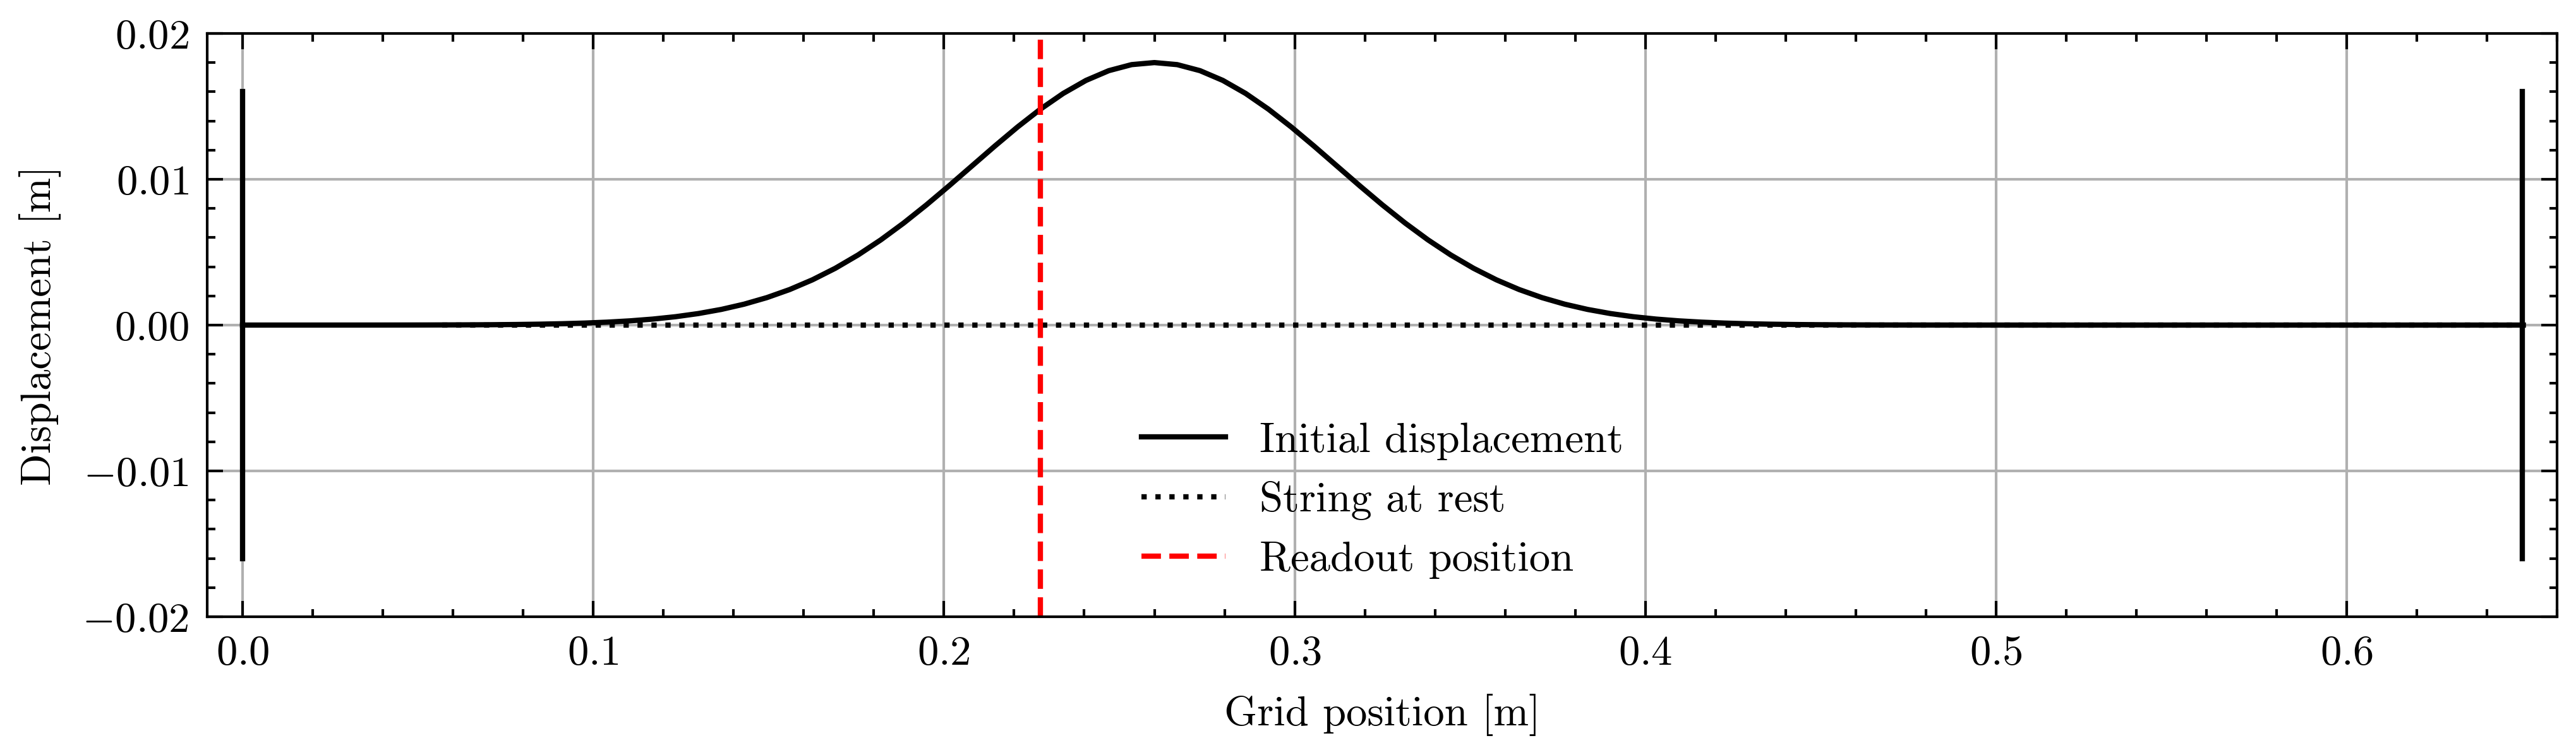

In [ ]:
# | output: true
# | layout-nrows: 1
from rich import print as rprint

n_timesteps = 1000
grid_idx = 35
xtime = np.linspace(0, 1, 15999)

fig, ax = plt.subplots(1, 1, figsize=(8, 2))
ax.plot(solver.grid, u0)
ax.grid(True)
ax.set_ylim(-0.02, 0.02)
ax.set_xlim(-0.01, 0.65 + 0.01)
ax.axhline(0, color="black", linestyle=":", xmin=0.1, xmax=0.99)
_ = ax.set_xlabel("Grid position [m]")
_ = ax.set_ylabel("Displacement [m]")
ax.axvline(solver.grid[grid_idx], color="red", linestyle="--")
ax.legend(["Initial displacement", "String at rest", "Readout position"])

# add two lines to represent the string is clamped
# Add vertical lines to represent the clamped (Dirichlet BC) boundaries
ax.axvline(solver.grid[0], linestyle="-", ymin=0.1, ymax=0.9, label="Dirichlet BC")
ax.axvline(solver.grid[-1], linestyle="-", ymin=0.1, ymax=0.9)

rprint(string_parameters.asdict())

In [ ]:
# | output: true


x_hat = model.apply(
    {"params": state.params},
    x,
)
gt = u_standarized[0, 1:, :, 0]
pred = x_hat[0, :, :, 0]

Markdown(
    f"At position {grid_idx / n_gridpoints * string_parameters.length:.03f}cm along the string, the network predicts:"
)

At position 0.225cm along the string, the network predicts:

In [ ]:
# print(gt.shape, pred.shape)

In [ ]:
x_segment = unstandardize(
    x_hat,
    np.array(cfg.datamodule.mean),
    np.array(cfg.datamodule.std),
)

Ground Truth,
Prediction,


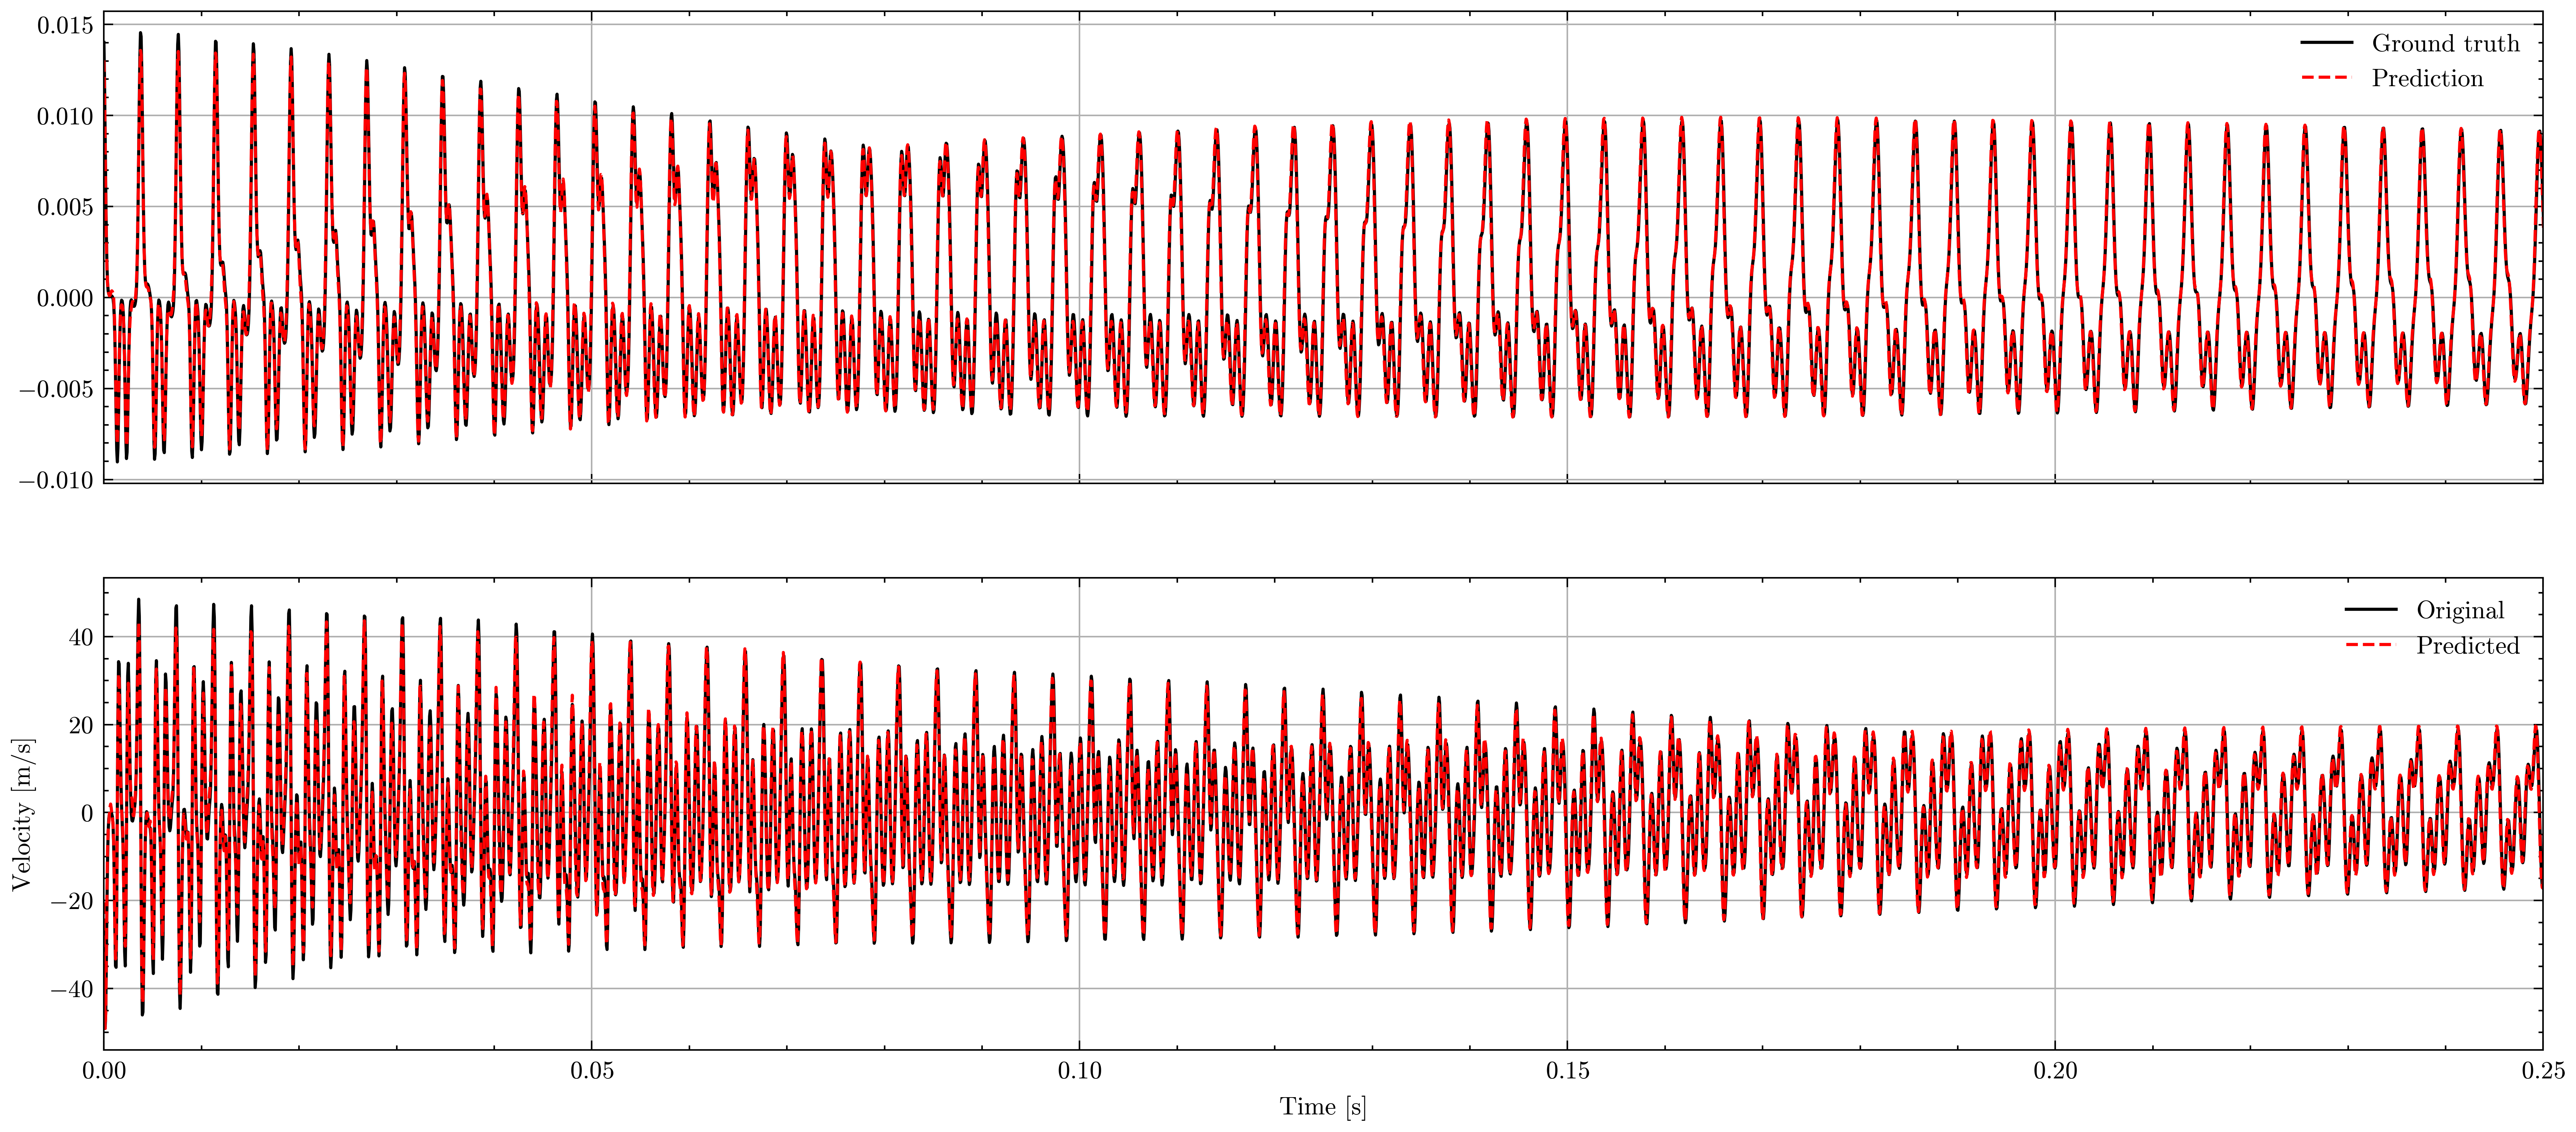

In [ ]:
# | output: true


# Plot time-domain comparison
fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ax[0].plot(
    xtime,
    u[1:, grid_idx],
    label="Ground truth",
)
ax[0].plot(
    xtime,
    x_segment[0, :, grid_idx, 0],
    label="Prediction",
    linestyle="--",
)
ax[0].legend(loc="upper right")
ax[0].grid()
ax[0].set_xlim(0, 0.25)

# Plot 3 (Velocity - second plot remains as is)
ax[1].plot(xtime, v[1:, grid_idx], label="Original")
ax[1].plot(xtime, x_segment[0, :, grid_idx, 1], label="Predicted", linestyle="--")
ax[1].set_ylabel("Velocity [m/s]")
ax[1].set_xlabel("Time [s]")
ax[1].legend(loc="upper right")
ax[1].grid()
ax[1].set_xlim(0, 0.25)

# save the audio
gt_file = results_dir / "gt.wav"
pred_file = results_dir / "pred.wav"
sf.write(gt_file, u[:, grid_idx] * 15, sampling_rate)
sf.write(pred_file, x_segment[0, :, grid_idx, 0] * 15, sampling_rate)


html_table = f"""
<table style="border-collapse: collapse; width: 60%; margin: auto; text-align: center;">
    <tr>
        <td>Ground Truth</td>
        <td><audio controls><source src="{gt_file}" type="audio/wav"></audio></td>
    </tr>
    <tr>
        <td>Prediction</td>
        <td><audio controls><source src="{pred_file}" type="audio/wav"></audio></td>
    </tr>
</table>
"""

# Display the table
display(HTML(html_table))

In [ ]:
# plt.plot(x_hat[0, :1000, 27, 0])
# plt.plot(u_standarized[0, 1:1001, 27, 0], linestyle="--")

# display(Audio(x_hat[0, :, 27, 0], rate=sampling_rate))
# display(Audio(u_standarized[0, 1:, 27, 0], rate=sampling_rate))

In [ ]:
from physmodjax.utils.metrics import mae_relative, mse_relative

In [ ]:
# print(x_hat.shape)
# print(u_standarized[:, 1:].shape)
# gt = u_standarized[:, 1:, :, 0]
# pred = x_hat[:, :, :, 0]
# print(gt.shape)
# print(pred.shape)

In [ ]:
# print(np.sum(gt**2))
# print(np.sum(gt**2 - pred**2))

In [ ]:
snr = 10 * np.log10(np.sum(gt**2) / np.sum((gt - pred) ** 2))
# print(snr)

In [ ]:
#
from itertools import product

angle_factors = [
    0.8,
    0.9,
    1.0,
    1.2,
    1.3,
]

radius_factor_factors = [
    1.0,
    0.99999,
    0.9999,
    0.999,
    0.99,
]

factors_list = list(product(angle_factors, radius_factor_factors))

In [ ]:
from pathlib import Path
import soundfile as sf
from scipy import signal

dynamics_model = model.dynamics_model()
modified_params = copy.deepcopy(state.params)

original_eigs = dynamics_model.apply(
    {"params": modified_params["dynamics"]},
    method=dynamics_model.get_eigenvalues,
)
# grid_idx = 27
filter_order = 4
cut_off_freq = 4000
sr = 16000

sos = signal.butter(filter_order, cut_off_freq, "low", fs=sr, output="sos")
table_data = []

for factors in factors_list:
    modified_eigs = multiply_eigenvalues(
        original_eigs,
        angle_factor=factors[0],
        radius_factor=factors[1],
    )

    _, modified_params_dynamics = dynamics_model.apply(
        {"params": modified_params["dynamics"]},
        mutable=["params"],
        eigenvalues=modified_eigs,
        method=dynamics_model.set_eigenvalues,
    )

    modified_params["dynamics"] = modified_params_dynamics["params"]
    modified_eigs = dynamics_model.apply(
        modified_params_dynamics,
        method=dynamics_model.get_eigenvalues,
    )
    modified_pred = (
        model.apply(
            {"params": modified_params},
            x,
        )
        * 0.01
    )

    single_position = modified_pred[0, :, grid_idx, 0]
    single_position_filtered = signal.sosfilt(sos, single_position)
    file_name = results_dir / f"angle_{factors[0]}_radius_{factors[1]}.wav"

    sf.write(
        file_name,
        single_position,
        sampling_rate,
    )
    sf.write(
        results_dir / f"angle_{factors[0]}_radius_{factors[1]}_filtered.wav",
        single_position_filtered,
        sampling_rate,
    )
    table_data.append((factors[0], factors[1], file_name))


# display(Audio(x_hat[0, :, grid_idx, 0], rate=sampling_rate))
# display(Audio(u_standarized[0, :, grid_idx, 0], rate=sampling_rate))
# display(Audio(single_position, rate=sampling_rate))
# display(Audio(single_position_filtered, rate=sampling_rate))

## Modifying the eigenvalues

We can modify the eigenvalues to have different pitch glides, because of the architecture of the network, the pitch glide is independent of the global dynamics of the network. Thus our network doesn't need to train on different material paramters to allow for changing the frequencies and decay rates.

In [ ]:
# | output: true
# | column: screen

# Extract unique angles and radii
angles = sorted(set(row[0] for row in table_data))
radii = sorted(set(row[1] for row in table_data))[::-1]
data_dict = {(angle, radius): file_name for angle, radius, file_name in table_data}


# Generate transposed HTML table
html_table = """
<table style="
    width: 100%;
    text-align: center;
    table-layout: fixed;
    border-collapse: collapse;">
"""
html_table += (
    "<tr><th style='text-align: center; font-weight: bold;'>Radius \\ Angle</th>"
    + "".join(
        f"<th style='text-align: center; font-weight: bold;'>{angle}</th>"
        for angle in angles
    )
    + "</tr>"
)

for radius in radii:
    html_table += (
        f"<tr><td style='text-align: center; font-weight: bold;'>{radius}</td>"
    )
    for angle in angles:
        file_name = data_dict.get((angle, radius), None)
        if file_name:
            html_table += (
                f"<td>"
                f"<audio controls style='width: 150px;'>"
                f"<source src='{file_name}' type='audio/wav'>"
                f"Your browser does not support the audio element."
                f"</audio><br>"
                f"</td>"
            )
        else:
            html_table += "<td>N/A</td>"
    html_table += "</tr>"

html_table += "</table>"

# Display the table
display(HTML(html_table))

Radius \ Angle,0.8,0.9,1.0,1.2,1.3
1.0,Your browser does not support the audio element.,Your browser does not support the audio element.,Your browser does not support the audio element.,Your browser does not support the audio element.,Your browser does not support the audio element.
0.99999,Your browser does not support the audio element.,Your browser does not support the audio element.,Your browser does not support the audio element.,Your browser does not support the audio element.,Your browser does not support the audio element.
0.9999,Your browser does not support the audio element.,Your browser does not support the audio element.,Your browser does not support the audio element.,Your browser does not support the audio element.,Your browser does not support the audio element.
0.999,Your browser does not support the audio element.,Your browser does not support the audio element.,Your browser does not support the audio element.,Your browser does not support the audio element.,Your browser does not support the audio element.
0.99,Your browser does not support the audio element.,Your browser does not support the audio element.,Your browser does not support the audio element.,Your browser does not support the audio element.,Your browser does not support the audio element.


or we can also add some random noise to their placement for creative purposes

In [ ]:
# | output: true
from pathlib import Path

import soundfile as sf
from scipy import signal

dynamics_model = model.dynamics_model()
modified_params = copy.deepcopy(state.params)

original_eigs = dynamics_model.apply(
    {"params": modified_params["dynamics"]},
    method=dynamics_model.get_eigenvalues,
)

# grid_idx = 27
# add random noise to the eigenvalues
rng = np.random.default_rng(42)
noise = rng.normal(0, 0.001, original_eigs.shape)
noise_real = rng.normal(0, 0.001, original_eigs.shape)
modified_eigs = original_eigs + (noise + noise * 1j)

noise = rng.normal(0, 0.1, original_eigs.shape)
noise_real = rng.normal(0.0, 0.0001, original_eigs.shape)
very_modified_eigs = original_eigs + (noise_real + noise * 1j)

# assert np.allclose(original_eigs, modified_eigs)
# print(original_eigs[:10])
# print(modified_eigs[:10])
_, modified_params_dynamics = dynamics_model.apply(
    {"params": modified_params["dynamics"]},
    mutable=["params"],
    eigenvalues=modified_eigs,
    method=dynamics_model.set_eigenvalues,
)

_, very_modified_params_dynamics = dynamics_model.apply(
    {"params": modified_params["dynamics"]},
    mutable=["params"],
    eigenvalues=very_modified_eigs,
    method=dynamics_model.set_eigenvalues,
)
modified_params["dynamics"] = modified_params_dynamics["params"]

modified_pred = (
    model.apply(
        {"params": modified_params},
        x,
    )
    * 0.01
)
modified_params["dynamics"] = very_modified_params_dynamics["params"]

very_modified_pred = (
    model.apply(
        {"params": modified_params},
        x,
    )
    * 0.01
)

single_position = modified_pred[0, :, grid_idx, 0]
single_position_very_modified = very_modified_pred[0, :, grid_idx, 0]
file_name = results_dir / f"detuned_pred.wav"
file_name_very_modified = results_dir / f"very_detuned_pred.wav"


sf.write(
    file_name,
    single_position,
    sampling_rate,
)

sf.write(
    file_name_very_modified,
    single_position_very_modified,
    sampling_rate,
)

html_table = f"""
<table style="border-collapse: collapse; width: 60%; margin: auto; text-align: center;">
    <tr>
        <td>Original Prediction</td>
        <td><audio controls><source src="{gt_file}" type="audio/wav"></audio></td>
    </tr>
    <tr>
        <td>with some random noise</td>
        <td><audio controls><source src="{file_name}" type="audio/wav"></audio></td>
    </tr>
    <tr>
        <td>with a lot of noise</td>
        <td><audio controls><source src="{file_name_very_modified}" type="audio/wav"></audio></td>
    </tr>
</table>
"""

# # Display the table
display(HTML(html_table))

# display(Audio(x_hat[0, :, grid_idx, 0], rate=sampling_rate))
# display(Audio(u_standarized[0, :, grid_idx, 0], rate=sampling_rate))
# display(Audio(single_position, rate=sampling_rate))
# display(Audio(single_position_very_modified, rate=sampling_rate))
# display(Audio(single_position_filtered, rate=sampling_rate))

Original Prediction,
with some random noise,
with a lot of noise,


## 2D Prediction

::: {layout-ncol=1}

{{< video assets/2d_snapshot.mp4 loop="true" title="2D Prediction" >}}

Ground truth (left) and prediction (right) of the network up to 100ms. The network predicts successive blocks of 399 timesteps. We use the last timestep of the previous block as the initial condition for the next block. 
:::


### Audio

In [ ]:
# | output: true

grid_idx_x = 16
grid_idx_y = 20
n_gridpoints_x = 41
n_gridpoints_y = 37
Markdown(
    f"At position ({grid_idx_x / n_gridpoints_x * 0.4:.03f}, {grid_idx_y / n_gridpoints_y * 0.36:.03f}) cm on the membrane, the network predicts:"
)

At position (0.156, 0.195) cm on the membrane, the network predicts:

In [ ]:
# | output: true

html_table = f"""
<table style="border-collapse: collapse; width: 60%; margin: auto; text-align: center;">
    <tr>
        <td>Ground truth</td>
        <td><audio controls><source src="assets/gt_16_20_0.wav" type="audio/wav"></audio></td>
    </tr>
    <tr>
        <td>Prediction</td>
        <td><audio controls><source src="assets/ar_pred_16_20_0.wav" type="audio/wav"></audio></td>
    </tr>
</table>
"""

# Display the table
display(HTML(html_table))

Ground truth,
Prediction,
